In [21]:
import pandas as pd


In [23]:
rfm = pd.read_csv(r'C:\Users\HP\Desktop\retailpulse_project\outputs\rfm_features.csv')

In [24]:
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326          1  77183.60        1        1        4   
1     12347.0        2          7   4310.00        4        4        4   
2     12348.0       75          4   1797.24        2        3        4   
3     12349.0       19          1   1757.55        3        1        4   
4     12350.0      310          1    334.40        1        1        2   

   RFM_Score  
0        114  
1        444  
2        234  
3        314  
4        112  


In [25]:
print(rfm.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score',
       'M_Score', 'RFM_Score'],
      dtype='str')


In [26]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

In [27]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

features.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [29]:
scaled_features[:7]

array([[ 2.33457414, -0.4250965 ,  8.36301037],
       [-0.90534032,  0.3544168 ,  0.2516989 ],
       [-0.17535959, -0.03533985, -0.02798783],
       [-0.73534481, -0.4250965 , -0.03240559],
       [ 2.17457836, -0.4250965 , -0.19081155],
       [-0.5653493 ,  0.48433568,  0.05090628],
       [ 1.11460635, -0.4250965 , -0.21812619]])

In [30]:
#find the optimal number of clusters using the elbow method

from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

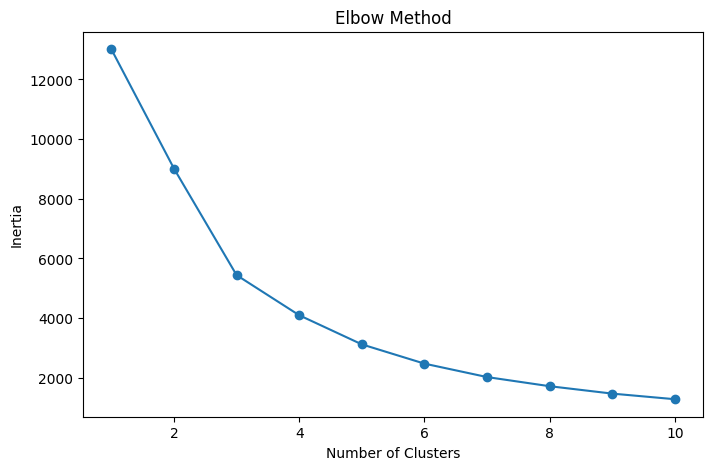

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [32]:
n_clusters = 3

In [33]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_features)

In [34]:
rfm[['CustomerID', 'Cluster']].head()

,CustomerID,Cluster
0,12346.0,0
1,12347.0,1
2,12348.0,1
3,12349.0,1
4,12350.0,0


In [35]:
rfm['Cluster'].value_counts()

Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_features,
    rfm['Cluster']
)

print("Silhouette Score:", score)

Silhouette Score: 0.5942233320872992


In [37]:
cluster_summary = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


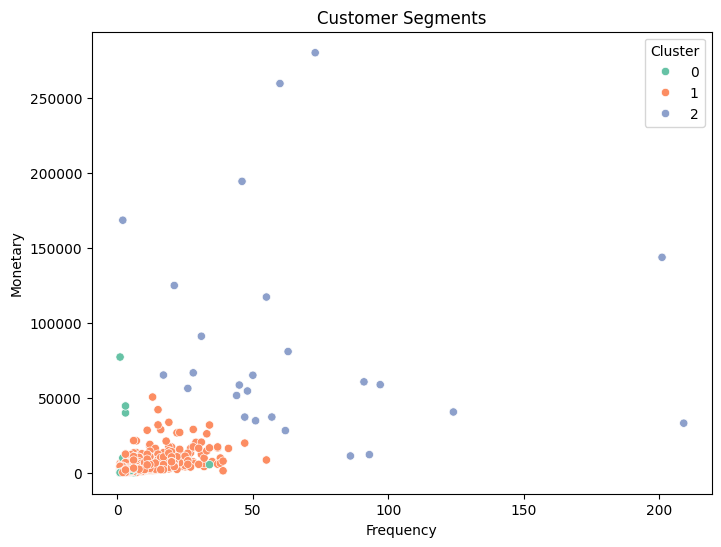

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segments")
plt.show()

BUSNIESS INTERPRETATIONN

In [40]:
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,247.106285,1.582255,629.663689
1,41.454180,4.672755,1849.670202
2,6.038462,66.423077,85826.078077


In [43]:
#table format

business_summary = pd.DataFrame({
    "Cluster":[0,1,2],
    "Segment":["At-Risk Customers",
               "Loyal Customers",
               "VIP Customers"],
    "Action":[
        "Re-engagement campaigns",
        "Upselling and recommendations",
        "Loyalty rewards"
    ]
})

business_summary

,Cluster,Segment,Action
0,0,At-Risk Customers,Re-engagement campaigns
1,1,Loyal Customers,Upselling and recommendations
2,2,VIP Customers,Loyalty rewards


In [45]:
#insights using python

print("Cluster 0 -> At-Risk Customers")
print("High recency, low frequency, low monetary value")

print("\nCluster 1 -> Loyal Customers")
print("Moderate recency, frequency and monetary value")

print("\nCluster 2 -> VIP Customers")
print("Recent buyers with highest spending and frequency")

Cluster 0 -> At-Risk Customers
High recency, low frequency, low monetary value

Cluster 1 -> Loyal Customers
Moderate recency, frequency and monetary value

Cluster 2 -> VIP Customers
Recent buyers with highest spending and frequency


## Business Interpretation

### Cluster 0 - At-Risk Customers

- Highest Recency (247 days)
- Lowest Frequency (1.58 purchases)
- Lowest Monetary Value (₹629.66)

Business Action:
- Send re-engagement campaigns
- Offer discounts and coupons
- Encourage repeat purchases

---

### Cluster 1 - Loyal Customers

- Moderate Recency (41 days)
- Moderate Frequency (4.67 purchases)
- Moderate Monetary Value (₹1849.67)

Business Action:
- Recommend related products
- Encourage upselling
- Provide personalized offers

---

### Cluster 2 - VIP Customers

- Lowest Recency (6 days)
- Highest Frequency (66.42 purchases)
- Highest Monetary Value (₹85826.08)

Business Action:
- Reward loyalty
- Offer premium memberships
- Provide exclusive discounts and early access

## DBSCAN Clustering

In [47]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(
    scaled_features
)

In [48]:
rfm['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    4297
-1      41
Name: count, dtype: int64

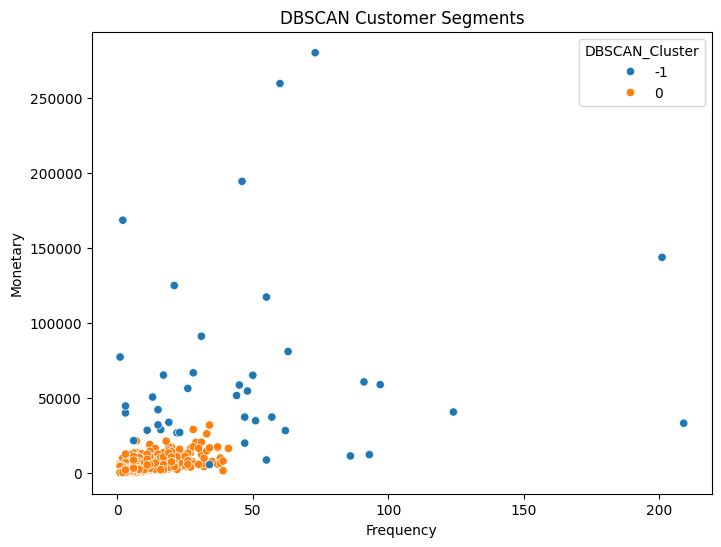

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='DBSCAN_Cluster',
    palette='tab10'
)

plt.title("DBSCAN Customer Segments")

plt.show()

In [57]:
rfm.to_csv(r"C:\Users\HP\Desktop\retailpulse_project\outputs\customer_segments.csv", index=False)